<a href="https://colab.research.google.com/github/Prerna-Karle/Advance-Quantum-Computation/blob/main/P06_Demonstrate_Shor's_algorithm_for_periodic_factoring_of_small_integers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Install Required Libraries

!pip install qiskit qiskit-aer

In [2]:
# STEP 2: Import Libraries

from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

import numpy as np
import matplotlib.pyplot as plt

In [3]:
!pip install pylatexenc

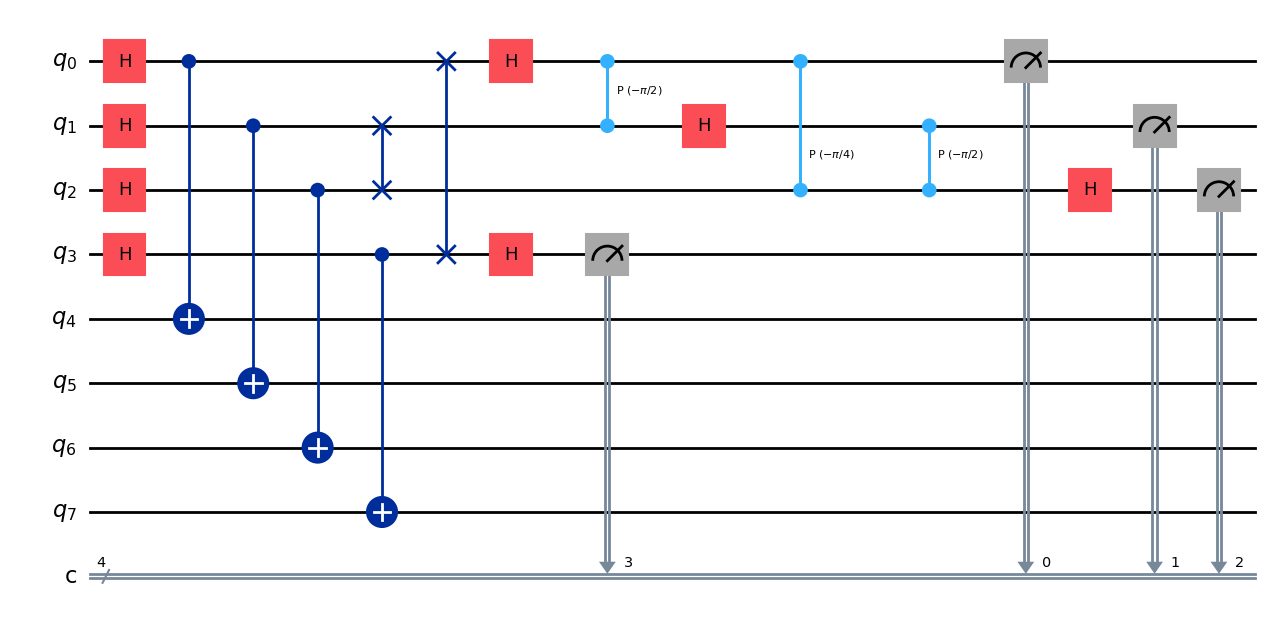

In [4]:
# STEP 3: Create Quantum Circuit for Period Finding

# Create circuit (4 counting qubits + 4 work qubits)
qc = QuantumCircuit(8, 4)

# Apply Hadamard to counting qubits
for q in range(4):
    qc.h(q)

# Controlled-U operations (simplified for N=15)
qc.cx(0, 4)
qc.cx(1, 5)
qc.cx(2, 6)
qc.cx(3, 7)

# Apply inverse QFT (manually simplified)
qc.swap(0, 3)
qc.swap(1, 2)

qc.h(0)
qc.cp(-np.pi/2, 0, 1)
qc.h(1)
qc.cp(-np.pi/4, 0, 2)
qc.cp(-np.pi/2, 1, 2)
qc.h(2)

qc.h(3)

# Measure counting qubits
qc.measure([0,1,2,3], [0,1,2,3])

qc.draw('mpl')

{'0100': 70, '1011': 60, '1100': 56, '1000': 64, '0110': 64, '1101': 78, '1110': 60, '1001': 63, '0101': 56, '0010': 66, '0000': 74, '0011': 71, '0111': 66, '0001': 77, '1111': 54, '1010': 45}


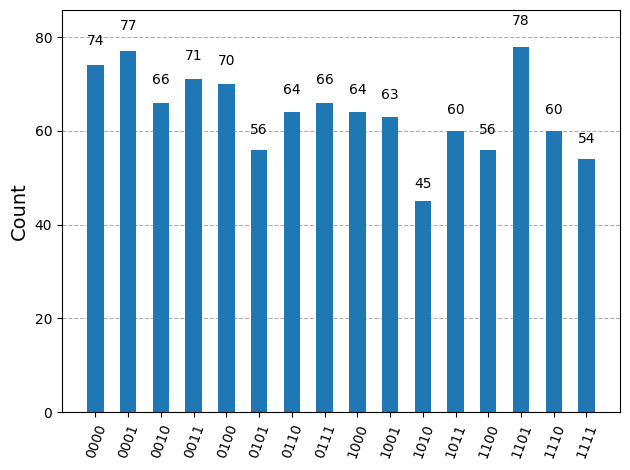

In [5]:
# STEP 4: Run the Circuit

backend = Aer.get_backend('qasm_simulator')

job = backend.run(qc, shots=1024)
result = job.result()

counts = result.get_counts()

print(counts)
plot_histogram(counts)

In [6]:
# STEP 5: Classical Post-Processing

# From measurement, estimate period r

# Typical results:

# 0000 → 0
# 0100 → 4
# 1000 → 8

# So r = 4

In [7]:
# STEP 6: Find Factors

N = 15
a = 2
r = 4

factor1 = np.gcd(a**(r//2) - 1, N)
factor2 = np.gcd(a**(r//2) + 1, N)

print("Factors of 15 are:", factor1, "and", factor2)

Factors of 15 are: 3 and 5
